# Comparison of reskilling simulation runs
Felix Zaussinger | 21.11.2022

**Core Analysis Goal(s)**
1. Gather the data of all baseline simulations (1), with/ (2) without regional constraints to (a) optimally targeted reskilling and (b) random reskilling scenario.
2. Run this comparison for the three different viability thresholds (low, mid, high).
3. Compare the distributions and run tests on significant differences.

**Key Insight(s)**
1.
2.
3.

In [681]:
import copy
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

from tqdm import tqdm
import pickle
from scipy import stats

from src.modelling.reskilling import ReskillingPathways
rp = ReskillingPathways()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Read data

##### Define model setting combinations

In [682]:
year = 2019
job_pools = ["brown_techchange"]  # ["coal", "brown_techchange", "brown"]
threshold = "viable-isco4d"  # ["viable-low", "low", "perc", "emp"]
regional_constraints = ["regC", "no-regC"]
reskilling_modes = [
    #"baseline",
    "reskill-random",
    "reskill-coreWeight",
    #"reskill-digital",
    # "coreness_percentile",
    "reskill-optimal",
]

coeff_pool_mapping = {
    "FFPOTC": "COEFF_share_brown_slt"
}

scenario_mapping = {"job_pool": {"coal": "CPO", "brown_techchange": "FFPOTC", "brown": "FFPO"}}

# select True if model results should be updated
overwrite_model_results = False

##### Preprocessing of model outputs

In [683]:
# -----------------------------------------------------------------------
# Collect raw model output across all options (reg/no-reg) and scenarios
# -----------------------------------------------------------------------

# names and paths
folder_name = "reskilling_final_thresh-{threshold}-v2"
fmt_string = "{reskilling_mode}_wage-opt_{regional_constraint}_{year}"
output_dir = os.path.join(useful_paths.data_processed, "eulfs", "reskilling_model_results")
fname = "model_data_tidy_{}_{}".format(year, threshold)

if overwrite_model_results:
    # iterate across all options
    data_store = {}

    for reskilling_mode in reskilling_modes:
        for regional_constraint in regional_constraints:
            fpath = os.path.join(
                useful_paths.figure_dir,
                #"test",  # todo: delete after testing
                folder_name.format(threshold=threshold),
                fmt_string.format(
                    reskilling_mode=reskilling_mode,
                    regional_constraint=regional_constraint,
                    year=year
                ),
                "{}.pkl".format(
                    fmt_string.format(
                        reskilling_mode=reskilling_mode,
                        regional_constraint=regional_constraint,
                        year=year
                    )
                ),
            )
            data_store[
                (threshold, reskilling_mode, regional_constraint)
            ] = pd.read_pickle(fpath)

    # save to pickle
    fdir_out = os.path.join(
        useful_paths.figure_dir,
        #"test",
        folder_name.format(threshold=threshold),
        "model_data_store.pkl"
    )

    with open(fdir_out, "wb") as handle:
        pickle.dump(data_store, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # -----------------------------------------------------------------------
    # Build up aggregated data cube of modelling results across all scenarios
    # -----------------------------------------------------------------------
    data_tidy = []
    for model_version in tqdm(list(data_store.keys())):
        # threshold - reskilling - regional constraint
        sub_dict = data_store[model_version]

        for job_pool in job_pools:
            # pool - country - DATA
            df_pool = pd.concat(list(sub_dict[job_pool].values()))

            # only keep select variables
            df_pool_sel = df_pool

            # add metadata of model run
            df_pool_sel["job_pool"] = job_pool
            df_pool_sel["viability_threshold"] = model_version[0]
            df_pool_sel["reskilling_mode"] = model_version[1]
            df_pool_sel["regional_constraint"] = model_version[2]

            # append
            data_tidy.append(df_pool_sel)

    df_tidy = pd.concat(data_tidy)
    df_tidy = df_tidy.reset_index()

    # -----------------------------------------------------------------------
    # Clean data set
    # -----------------------------------------------------------------------
    # rename job pools
    df_tidy = df_tidy.replace(scenario_mapping)

    # make sure entries for countries with missing earnings data_transitions are coded as NaNs
    earnings_data_missing = ["AT", "ES", "CZ", "NO", "SE", "GR", "IS", "UK"]
    df_tidy.loc[
        df_tidy["COUNTRYW"].isin(earnings_data_missing),
        "earnings_delta_closest_switch_sum_mio",
    ] = np.nan

    # add nace labels
    df_tidy = pd.merge(df_tidy, rp.nace_labels, on="NACE1D", how="left")

    # Save concatenated results data
    utils.save_df_to_files(
        df=df_tidy,
        output_dir=output_dir,
        fname_no_ext=fname
    )
else:
    # read results from existing model run
    df_tidy = pd.read_pickle(os.path.join(output_dir, fname + ".pkl"))

In [684]:
# only keep reskilling steps 0 to 20?
cols2keep = ~df_tidy.columns.str.contains("step_21")
df_tidy = df_tidy.loc[:, cols2keep]

##### Reduce data set to core sectors for paper

In [685]:
df_tidy = df_tidy.loc[df_tidy["paper_selection"]]

##### Mask income data for countries that don't report data

In [686]:
iso_missing_earnings = ["AT", "CZ", "ES", "GR", "IS", "NO", "SE", "UK"]

##### Wide to long, Normalisation of earnings data

In [687]:
# define columns to be melted
transitions_cols = df_tidy.columns[df_tidy.columns.str.startswith("n_viable_transitions")].values
viability_cols = df_tidy.columns[df_tidy.columns.str.startswith("n_viable_transitions")].values

# per observation
earnings_cols = df_tidy.columns[df_tidy.columns.str.startswith("earnings_delta_closest_switch_sum_step")].values
index_cols = set(df_tidy.columns) - set(transitions_cols) - set(earnings_cols)

# per worker
earnings_cols_rel = df_tidy.columns[df_tidy.columns.str.startswith("earnings_delta_closest_switch_step")].values
index_cols_rel = set(df_tidy.columns) - set(transitions_cols) - set(earnings_cols_rel)

# Re-mask income data for countries that don’t report data (!)
iso_missing_earnings = ["AT", "CZ", "ES", "GR", "IS", "NO", "SE", "UK"]
df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols] = np.nan
df_tidy.loc[df_tidy["COUNTRYW"].isin(iso_missing_earnings), earnings_cols_rel] = np.nan

# TODO: THIS IS ONLY VALID IF RUNNING THE CODE FOR THE FFPOTC JOB POOL ALONE (!!!!!!!)
# can back-calculate from region-sector pairs because I also sum up all COEFF's in the reskilling simulations
norm_factor = "COEFF_share_brown_slt"
for col in earnings_cols_rel:
    df_tidy[col] = df_tidy[col] / df_tidy[norm_factor]

# melt to long format
df_tidy_long_transitions = df_tidy.melt(id_vars=index_cols, value_vars=transitions_cols, var_name="reskilling_step", value_name="n_transitions")
df_tidy_long_transitions["reskilling_step"] = df_tidy_long_transitions["reskilling_step"].str.split("_").str[-1].astype(int)

# absolute earnings losses (per-observation numbers)
df_tidy_long_earnings_abs = df_tidy.melt(id_vars=index_cols, value_vars=earnings_cols, var_name="reskilling_step", value_name="earnings_delta_abs")
df_tidy_long_earnings_abs["reskilling_step"] = df_tidy_long_earnings_abs["reskilling_step"].str.split("_").str[-1].astype(int)

# relative earnings losses (per-worker numbers)
df_tidy_long_earnings_rel = df_tidy.melt(id_vars=index_cols_rel, value_vars=earnings_cols_rel, var_name="reskilling_step", value_name="earnings_delta_rel")
df_tidy_long_earnings_rel["reskilling_step"] = df_tidy_long_earnings_rel["reskilling_step"].str.split("_").str[-1].astype(int)

# other earnings figures
df_tidy_long_earnings_abs["earnings_delta_abs_mio"] = df_tidy_long_earnings_abs["earnings_delta_abs"] / 10 ** 6
df_tidy_long_earnings_abs["earnings_delta_abs_bio"] = df_tidy_long_earnings_abs["earnings_delta_abs"] / 10 ** 9

df_tidy_long_earnings_rel["earnings_delta_rel_mio"] = df_tidy_long_earnings_rel["earnings_delta_rel"] / 10 ** 6
df_tidy_long_earnings_rel["earnings_delta_rel_bio"] = df_tidy_long_earnings_rel["earnings_delta_rel"] / 10 ** 9

In [688]:
df_tidy_long_earnings_rel.shape
df_tidy_long_earnings_abs.shape

(211806, 86)

In [689]:
earnings_abs = df_tidy_long_earnings_abs[["NACE1D_label", "NACE1D_label_short", "COUNTRYW", "NUTS_ID", "regional_constraint", "job_pool", "reskilling_mode", "reskilling_step", "earnings_delta_abs", "earnings_delta_abs_mio", "earnings_delta_abs_bio"]]

earnings_rel = df_tidy_long_earnings_rel[["NACE1D_label", "NACE1D_label_short", "COUNTRYW", "NUTS_ID", "regional_constraint", "job_pool", "reskilling_mode", "reskilling_step", "earnings_delta_rel", "earnings_delta_rel_mio", "earnings_delta_rel_bio"]]

In [690]:
earnings_rel.describe()

,reskilling_step,earnings_delta_rel,earnings_delta_rel_mio,earnings_delta_rel_bio
count,"211,806.00","139,356.00","139,356.00","139,356.00"
mean,10.00,"-1,018.22",-0.00,-0.00
std,6.06,"1,681.83",0.00,0.00
min,0.00,"-25,362.20",-0.03,-0.00
25%,5.00,"-1,260.52",-0.00,-0.00
50%,10.00,-515.80,-0.00,-0.00
75%,15.00,-152.77,-0.00,-0.00
max,20.00,"12,630.76",0.01,0.00


In [691]:
# merge
df_tidy_long_earnings_merged = pd.merge(
    earnings_abs, earnings_rel, on=["COUNTRYW", "NUTS_ID", "NACE1D_label", "regional_constraint", "job_pool", "reskilling_mode", "reskilling_step"], how="left", suffixes=("", "_drop")
)

cols2drop = df_tidy_long_earnings_merged.columns.str.contains("_drop")
df_tidy_long_earnings_merged = df_tidy_long_earnings_merged.loc[:, ~cols2drop]
df_tidy_long_earnings_merged.shape

(211806, 14)

## Visualisation

##### Plotting parameters

In [692]:
from statannotations.Annotator import Annotator

pairs = []
reskilling_steps = np.arange(0, df_tidy_long_transitions["reskilling_step"].max())
for step in reskilling_steps:
    pair = ((step, "reskill-random"), (step, "reskill-optimal"))
    pairs.append(pair)

alpha = 0.001
test = "Kruskal"
comparisons_correction = "Benjamini-Hochberg"
text_format = "star"
loc = "outside"
show_test_name = False
verbose = False

# shared across plot versions
job_pool = "FFPOTC"
hue_order_main = ["reskill-optimal", "reskill-random"]
hue_order_si = ["reskill-optimal", "reskill-coreWeight", "reskill-random"]
order = reskilling_steps
palette = "BrBG_r"
figsize=(6, 4)

# error bars
errorbar = ("ci", 99) # CI takes a PI from the bootstrap distribution (!!!)
n_boot = 1000  # size of bootstrap sample: 1000
estimator = np.median
seed = 42
draw_kde_plots = False

# labelling
ylabel_transitions = "Viable job transitions (-)"
ylabel_earnings = "$\Delta$ Annual Income (€)"
xlabel = "Reskilling journey step"

# annotate units to top of y-axis
yax_title_transitions = "#"
yax_title_earnings = "€"
yax_title_earnings_mio = "€m"
yax_title_earnings_bio = "€bn"
yax_title_scaling_transitions = 1.01
yax_title_scaling_earnings = 1.05

# output dir
results_dir = os.path.join(
    useful_paths.figure_dir,
    folder_name.format(threshold=threshold)
)

#### Reskilling journey visualisations
- [https://seaborn.pydata.org/tutorial/error_bars.html](https://seaborn.pydata.org/tutorial/error_bars.html), [https://acclab.github.io/bootstrap-confidence-intervals.html](https://acclab.github.io/bootstrap-confidence-intervals.html)
- **The confidence interval is constructed by taking a percentile interval of the bootstrap distribution**. By default errorbar="ci" draws a 95% confidence interval.
- The nonparametric approach to representing uncertainty uses bootstrapping: a procedure where the dataset is randomly resampled with replacement a number of times, and the estimate is recalculated from each resample. This procedure creates a distribution of statistics approximating the distribution of values that you could have gotten for your estimate if you had a different sample. The nonparametric bootstrap has advantages similar to those of the percentile interval: it will naturally adapt to skewed and bounded data in a way that a standard error interval cannot. It is also more general. While the standard error formula is specific to the mean, error bars can be computed using the bootstrap for any estimator
- **Percentile intervals also represent the range where some amount of the data fall**, but they do so by **computing those percentiles directly from your sample**. By default, errorbar="pi" will show a 95% interval, ranging from the 2.5 to the 97.5 percentiles. You can choose a different range by passing a size parameter, e.g., to show the inter-quartile range.

##### Joyplots (stacked histograms)

In [693]:
# data_transitions = df_tidy_long_transitions.loc[
#     (df_tidy_long_transitions["job_pool"] == job_pool) & (df_tidy_long_transitions["reskilling_mode"].isin(hue_order_main))
# ]
#
# data_earnings = df_tidy_long_earnings_merged.loc[
#     (df_tidy_long_earnings_merged["job_pool"] == job_pool) & (df_tidy_long_earnings_merged["reskilling_mode"].isin(hue_order_main))
#     ]

In [694]:
import joypy
from matplotlib import cm

if draw_kde_plots:
    # variables
    x = "n_transitions"
    y = "reskilling_step"
    reg_constraint = "regC"

    # params
    x_range = np.arange(-3, 22, 5)
    bins=30
    kind="counts"
    figsize=(3,5)

    # subset data
    data = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["job_pool"] == job_pool) &
        (df_tidy_long_transitions["regional_constraint"] == "regC") &
        (df_tidy_long_transitions["reskilling_mode"] == "reskill-optimal")
    ]

    # create fancy joyplot
    labels=[y if y%1==0 else None for y in list(data["reskilling_step"].unique())]

    fig, axes = joypy.joyplot(
        data=data,
        by=y,
        column=x,
        labels=labels,
        range_style='own',
        x_range=x_range,
        bins=bins,
        grid="y",
        hist=False,
        fade=True,
        linewidth=1,
        legend=False,
        figsize=figsize,
        colormap=cm.autumn
    )

    #for ax in axes:
    fig.text(-0.02, 0.5, xlabel, va='center', rotation='vertical')
    plt.xlabel(ylabel_transitions)
    plt.axvline(1, linestyle="--", linewidth=1, color="lightgrey")

    # save
    fname = os.path.join(
        results_dir,
        "{}_{}_by_{}_{}_joyplot.{}".format(job_pool, y, x, reg_constraint, "png"),
    )
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_{}_joyplot.png".format(job_pool, y, x, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

    # mean and median per reskilling step
    fname = os.path.join(
        results_dir,
        "{}_{}_by_{}_{}_joyplot_data.{}".format(job_pool, y, x, reg_constraint, "csv"),
    )
    agg_data = data.groupby("reskilling_step").aggregate({x: [np.nanmean, np.nanmedian, np.nansum, np.count_nonzero]})
    agg_data.to_csv(fname)
    agg_data

In [695]:
if draw_kde_plots:
    # variables
    x = "earnings_delta_rel"
    y = "reskilling_step"
    reg_constraint = "regC"

    # params
    bins=30
    kind="counts"
    figsize=(3,5)

    # subset data
    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["job_pool"] == job_pool) &
        (df_tidy_long_earnings_merged["regional_constraint"] == "regC") &
        (df_tidy_long_transitions["reskilling_mode"] == "reskill-optimal")
    ]

    # create fancy joyplot
    labels=[y if y%1==0 else None for y in list(data["reskilling_step"].unique())]

    fig, axes = joypy.joyplot(
        data=data,
        by=y,
        column=x,
        labels=labels,
        range_style='own',
        bins=bins,
        grid="y",
        hist=False,
        fade=True,
        linewidth=1,
        legend=False,
        figsize=figsize,
        colormap=cm.autumn
    )

    #for ax in axes:
    fig.text(-0.02, 0.5, "Reskilling journey step", va='center', rotation='vertical')
    plt.xlabel(ylabel_earnings)
    plt.axvline(0, linestyle="--", linewidth=1, color="lightgrey")

    # save
    fname = os.path.join(
        results_dir,
        "{}_{}_by_{}_{}_joyplot.{}".format(job_pool, y, x, reg_constraint, "png"),
    )

    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_{}_joyplot.png".format(job_pool, y, x, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

    # mean and median per reskilling step
    fname = os.path.join(
        results_dir,
        "{}_{}_by_{}_{}_joyplot_data.{}".format(job_pool, y, x, reg_constraint, "csv"),
    )
    agg_data = data.groupby("reskilling_step").aggregate({x: [np.nanmean, np.nanmedian, np.nansum, np.count_nonzero]})
    agg_data.to_csv(fname)
    agg_data

In [696]:
if draw_kde_plots:
    # variables
    x = "earnings_delta_abs"
    y = "reskilling_step"
    reg_constraint = "regC"

    # params
    bins=30
    kind="counts"
    figsize=(3,5)

    # subset data
    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["job_pool"] == job_pool) &
        (df_tidy_long_earnings_merged["regional_constraint"] == "regC") &
        (df_tidy_long_transitions["reskilling_mode"] == "reskill-optimal")
    ]

    # create fancy joyplot
    labels=[y if y%1==0 else None for y in list(data["reskilling_step"].unique())]

    fig, axes = joypy.joyplot(
        data=data,
        by=y,
        column=x,
        labels=labels,
        range_style='own',
        bins=bins,
        grid="y",
        hist=False,
        fade=True,
        linewidth=1,
        legend=False,
        figsize=figsize,
        colormap=cm.autumn
    )

    #for ax in axes:
    fig.text(-0.02, 0.5, "Reskilling journey step", va='center', rotation='vertical')
    plt.xlabel(ylabel_earnings)
    plt.axvline(0, linestyle="--", linewidth=1, color="lightgrey")

    # save
    fname = os.path.join(
        results_dir,
        "{}_{}_by_{}_{}_joyplot.{}".format(job_pool, y, x, reg_constraint, "png"),
    )
    plt.savefig(
        os.path.join(
            results_dir,
            "{}_{}_by_{}_{}_joyplot.png".format(job_pool, y, x, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

    # mean and median per reskilling step
    fname = os.path.join(
        results_dir,
        "{}_{}_by_{}_{}_joyplot_data.{}".format(job_pool, y, x, reg_constraint, "csv"),
    )
    agg_data = data.groupby("reskilling_step").aggregate({x: [np.nanmean, np.nanmedian, np.nansum, np.count_nonzero]})
    agg_data.to_csv(fname)
    agg_data

##### 2D KDE Plots

levels: int or vector

    Number of contour levels or values to draw contours at. A vector argument must have increasing values in [0, 1]. Levels correspond to iso-proportions of the density: e.g., 20% of the probability mass will lie below the contour drawn for 0.2. Only relevant with bivariate data.

thresh: number in [0, 1]

    Lowest iso-proportion level at which to draw a contour line. Ignored when levels is a vector. Only relevant with bivariate data.


In [697]:
if draw_kde_plots:
    # plotting params
    x="reskilling_step"
    y="n_transitions"
    hue="reskilling_mode"
    style=hue
    reg_constraint="regC"

    data = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["job_pool"] == job_pool) &
        (df_tidy_long_transitions["regional_constraint"] == "regC") &
        (df_tidy_long_transitions["reskilling_mode"].isin(hue_order_main))
    ]

    # plot
    ax = sns.kdeplot(data=data, x=x, y=y, hue=hue, fill=True, palette="BrBG")

    # axes limits and ticks
    xmin = -4
    xmax = 25
    ymin = -2
    ymax = 15

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # beautify legend
    # handles, labels = ax.get_legend_handles_labels()
    # legend_locs = [0, 1, 2]
    # handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
    # labels_new = ['Optimal', 'Random', None, None, None, None]
    # ax.legend(handles=handles, labels=labels, fancybox=False, frameon=False, loc="upper right")

    # styling
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(ylabel_transitions)
    ax.set_xlabel(xlabel)
    sns.despine()
    plt.tight_layout()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)

    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_kde.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

In [698]:
if draw_kde_plots:
    # plotting params
    x="reskilling_step"
    y="earnings_delta_rel"
    hue="reskilling_mode"
    style=hue
    reg_constraint="regC"

    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["job_pool"] == job_pool) &
        (df_tidy_long_earnings_merged["regional_constraint"] == "regC") &
        (df_tidy_long_earnings_merged["reskilling_mode"].isin(hue_order_main))
    ]

    # plot
    ax = sns.kdeplot(data=data, x=x, y=y, hue=hue, fill=True, palette="BrBG")

    # axes limits and ticks
    xmin = -4
    xmax = 25
    ymin = -6000
    ymax = 1000

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    # ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    # ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    # ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # beautify legend
    # handles, labels = ax.get_legend_handles_labels()
    # legend_locs = [0, 1, 2]
    # handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
    # labels_new = ['Optimal', 'Random', None, None, None, None]
    # ax.legend(handles=handles, labels=labels, fancybox=False, frameon=False, loc="upper right")

    # styling
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(ylabel_earnings)
    ax.set_xlabel(xlabel)
    sns.despine()
    plt.tight_layout()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)

    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_kde.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

In [699]:
if draw_kde_plots:
    # plotting params
    x="reskilling_step"
    y="earnings_delta_abs"
    hue="reskilling_mode"
    style=hue
    reg_constraint="regC"

    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["job_pool"] == job_pool) &
        (df_tidy_long_earnings_merged["regional_constraint"] == "regC") &
        (df_tidy_long_earnings_merged["reskilling_mode"].isin(hue_order_main))
    ]

    # plot
    ax = sns.kdeplot(data=data, x=x, y=y, hue=hue, fill=True, palette="BrBG")

    # axes limits and ticks
    xmin = -4
    xmax = 25
    ymin = -0.2*10**10
    ymax = 0.05*10**10

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    # ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    # ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    # ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # beautify legend
    # handles, labels = ax.get_legend_handles_labels()
    # legend_locs = [0, 1, 2]
    # handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
    # labels_new = ['Optimal', 'Random', None, None, None, None]
    # ax.legend(handles=handles, labels=labels, fancybox=False, frameon=False, loc="upper right")

    # styling
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(ylabel_earnings)
    ax.set_xlabel(xlabel)
    sns.despine()
    plt.tight_layout()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)

    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_kde.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5a: Transition numbers across reskilling journey, Main

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

9_reskill-random vs. 9_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.972e-235 Stat=1.070e+03
10_reskill-random vs. 10_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.003e-291 Stat=1.330e+03
11_reskill-random vs. 11_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=1.657e+03
12_reskill-random vs. 12_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=1.800e+03
13_reskill-random vs. 13_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, 

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


p-value annotation legend:
      ns: p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

9_reskill-random vs. 9_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=1.894e+03
10_reskill-random vs. 10_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=1.930e+03
11_reskill-random vs. 11_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=2.124e+03
12_reskill-random vs. 12_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=2.146e+03
13_reskill-random vs. 13_reskill-optimal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_

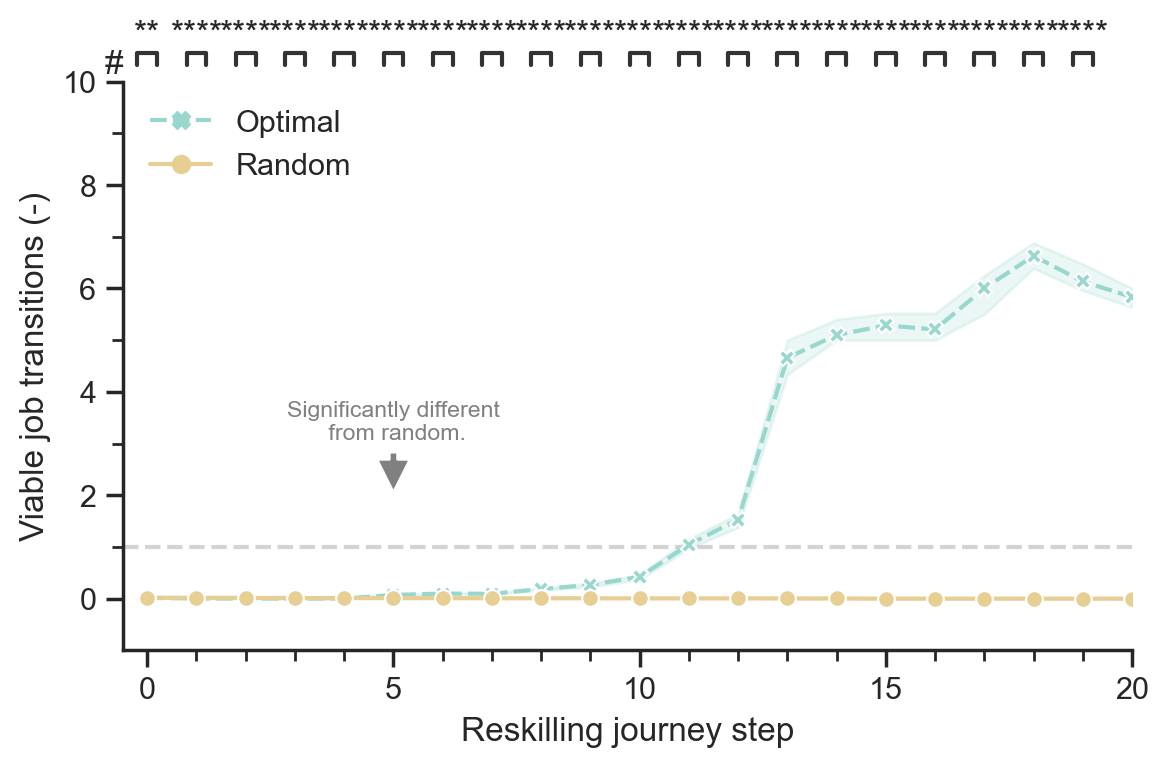

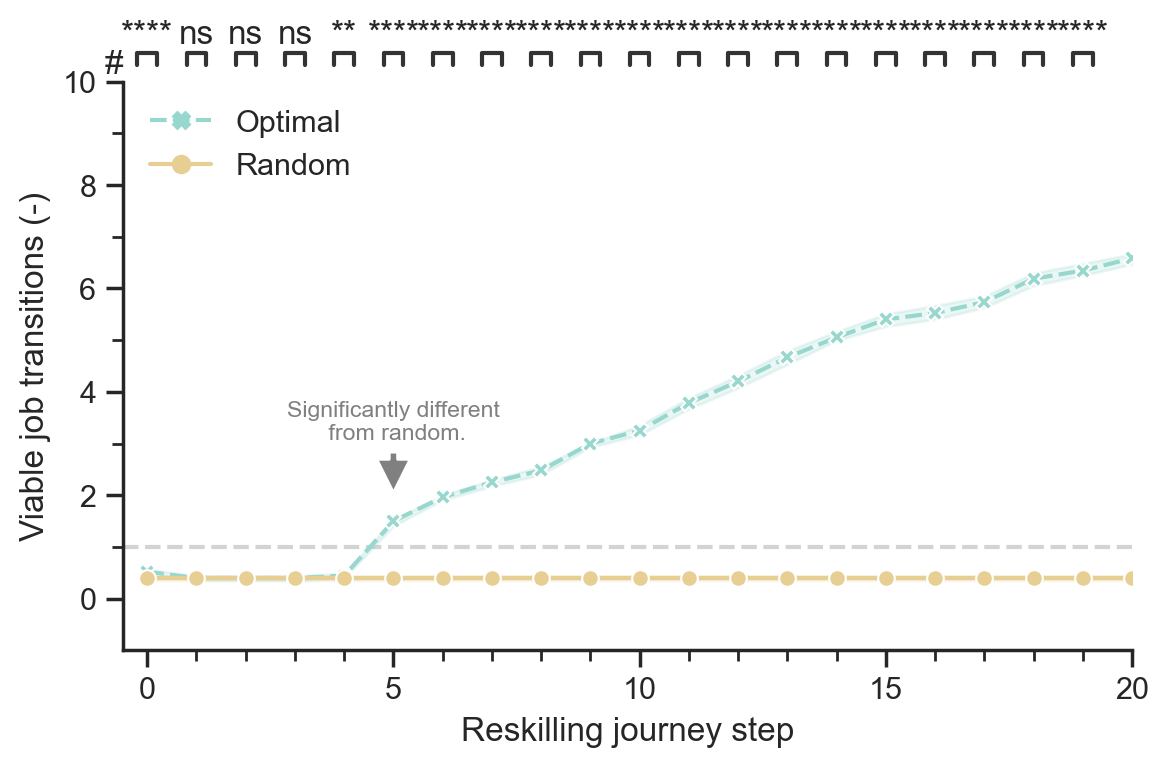

In [700]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"
hue = "reskilling_mode"
style = "reskilling_mode"  # "NACE1D"
size = None

# apply regional constraint?
for reg_constraint in regional_constraints:

    # subset data
    data = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == reg_constraint) &
        (df_tidy_long_transitions["reskilling_mode"].isin(hue_order_main))
    ]

    # lineplot
    figsize=(6, 4)
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order_main,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        n_boot=n_boot,
        errorbar=errorbar,
        palette=palette,
        seed=seed,
        ax=ax,
        legend="brief",
    )

    # axes limits and ticks
    xmin = -0.5
    xmax = 20
    ymin = -1
    ymax = 10

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # annotation
    x_sign, y_sign = 5, 2
    text = "Significantly different\n from random.".format(x_sign)
    ax.annotate(
        text, xy=(x_sign, y_sign),
        xytext=(x_sign, y_sign+1),
        fontsize="x-small",
        arrowprops=dict(facecolor='grey', shrink=0.05, width=3), color="grey",
        horizontalalignment='center', verticalalignment='bottom',
    )

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    legend_locs = [0, 1, 2]
    handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
    labels_new = ['Optimal', 'Random', None, None, None, None]
    ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="upper left")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs, data=data, x=x, y=y, order=order, hue=hue
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=True,
    )
    #annotator.apply_and_annotate()

    # styling
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(ylabel_transitions)
    ax.set_xlabel(xlabel)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()
    plt.tight_layout()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

In [701]:
assert 1 == 2

AssertionError: 

In [ ]:
# N of independent data points
data.loc[
    (data["regional_constraint"] == reg_constraint) &
    (data["reskilling_mode"] == "reskill-optimal") &
    (data["reskilling_step"] == 0)
].shape

In [ ]:
df_tidy_long_transitions["reskilling_mode"].unique()

##### Fig 5a: Transition numbers across reskilling journey, Regional Constraints

In [ ]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "regional_constraint"  # "NACE1D"
size = None

# lineplot
fig, ax = plt.subplots(figsize=figsize)

# subset data
data = df_tidy_long_transitions

sns.lineplot(
    data=data,
    x=x,
    y=y,
    hue=hue,
    hue_order=hue_order_main,
    style=style,
    size=size,
    dashes=True,
    markers=True,
    estimator=estimator,
    errorbar=errorbar,
    n_boot=n_boot,
    palette=palette,
    seed=seed,
    ax=ax,
    legend="brief"
)

# axes limits and ticks
xmax = 20
ymax = 10

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-1, ymax)

ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

x_sign, y_sign = 5, 3
text = "Significantly different\n from random.".format(x_sign)
ax.annotate(
    text, xy=(x_sign, y_sign),
    xytext=(x_sign, y_sign+1),
    fontsize="x-small",
    arrowprops=dict(facecolor='grey', shrink=0.05, width=3), color="grey",
    horizontalalignment='center', verticalalignment='bottom',
)

# annotate units to y-axis
ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

# beautify legend
handles, labels = ax.get_legend_handles_labels()
legend_locs = [1, 2, 4, 5]
handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
labels_new = [None, 'Optimal', 'Random', None, 'Reg. Constraint ON', 'Reg. Constraint OFF']
ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="upper left")

# styling
ax.axhline(1, linestyle="--", color="grey", zorder=0)
ax.set_ylabel(ylabel_transitions)
ax.set_xlabel(xlabel)
#plotting_utils.move_legend_to_right(ax)
sns.despine()

# save
out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
utils.ccdir(out_dir)
plt.savefig(
    os.path.join(
        out_dir,
        "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Fig 5a: Transition numbers across reskilling journey, Sectors, Appendix

In [ ]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label_short"  # "NACE1D"
size = None

# styling
hue_order_main = ["reskill-optimal"]
order = reskilling_steps
palette = "viridis"
figsize=(6, 4)

# apply regional constraint?
for reg_constraint in regional_constraints:

    data = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == reg_constraint) &
        (df_tidy_long_transitions[hue].isin(hue_order_main))
    ]

    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order_main,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=None,
        n_boot=n_boot,
        palette=palette,
        seed=seed,
        ax=ax,
        legend="brief"
    )

    # axes limits and ticks
    xmax = 20
    ymax = 10

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(-0.2, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(ylabel_transitions)
    ax.set_xlabel(xlabel)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5a: Transition numbers across reskilling journey, Sectors, Main

In [ ]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label"  # "NACE1D"
size = None

# styling
hue_order_main = ["reskill-optimal"]
palette = "viridis"
figsize=(3, 2)

# apply regional constraint?
for reg_constraint in regional_constraints:

    data = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == reg_constraint) &
        (df_tidy_long_transitions[hue].isin(hue_order_main))
    ]

    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order_main,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=None,
        n_boot=n_boot,
        palette=palette,
        seed=seed,
        ax=ax,
        legend=False
    )

    # axes limits and ticks
    xmax = 20
    ymax = 10

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(-.2, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left")

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

In [ ]:
# N of independent data points
data.loc[
    (data["reskilling_step"] == 0)
].shape

##### Fig 5a: Transition numbers across reskilling journey, Countries, Appendix

In [ ]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"  # "NACE1D"
size = None

# styling
hue_order_main = ["reskill-optimal"]
order = reskilling_steps
palette = "viridis"
figsize=(6, 4)

# apply regional constraint?
for reg_constraint in regional_constraints:

    data = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == reg_constraint) &
        (df_tidy_long_transitions[hue].isin(hue_order_main))
    ]

    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order_main,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=None,
        n_boot=n_boot,
        palette=palette,
        seed=seed,
        ax=ax,
        legend="brief"
    )

    # axes limits and ticks
    xmax = 20
    ymax = 10

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(-.2, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=labels[3:], fancybox=False, frameon=False, loc="upper left", ncol=2, fontsize="xx-small")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(ylabel_transitions)
    ax.set_xlabel(xlabel)
    sns.despine()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5a: Transition numbers across reskilling journey, Countries, Main

In [ ]:
# plotting parameters
x = "reskilling_step"
y = "n_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "COUNTRYW"  # "NACE1D"
size = None

# styling
hue_order_main = ["reskill-optimal"]
palette = "viridis"
figsize=(3, 2)

# apply regional constraint?
for reg_constraint in regional_constraints:

    data = df_tidy_long_transitions.loc[
        (df_tidy_long_transitions["regional_constraint"] == reg_constraint) &
        (df_tidy_long_transitions[hue].isin(hue_order_main))
    ]

    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order_main,
        style=style,
        size=size,
        dashes=True,
        markers=True,
        estimator=estimator,
        errorbar=None,
        n_boot=n_boot,
        palette=palette,
        seed=seed,
        ax=ax,
        legend=False,
    )

    # axes limits and ticks
    xmax = 20
    ymax = 10

    ax.set_xlim(-0.5, xmax)
    ax.set_ylim(-.2, ymax)

    ax.set_xticks(np.arange(0, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(0, xmax+1, 1), minor=True)
    ax.set_yticks(np.arange(0, ymax+1, 2), minor=False)
    ax.set_yticks(np.arange(0, ymax+1, 1), minor=True)

    # annotate units to y-axis
    ax.annotate(yax_title_transitions, xy=(0, yax_title_scaling_transitions), xytext=(0, yax_title_scaling_transitions), xycoords="axes fraction", textcoords="offset points", ha="right")

    # styling
    ax.axhline(1, linestyle="--", color="grey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel(None)
    #plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Main

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\statannotations\Annotator.py:769: UserWarning: Changing alpha without updating pvalue_thresholds can result in inconsistent plotting results
  warnings.warn("Changing alpha without updating "


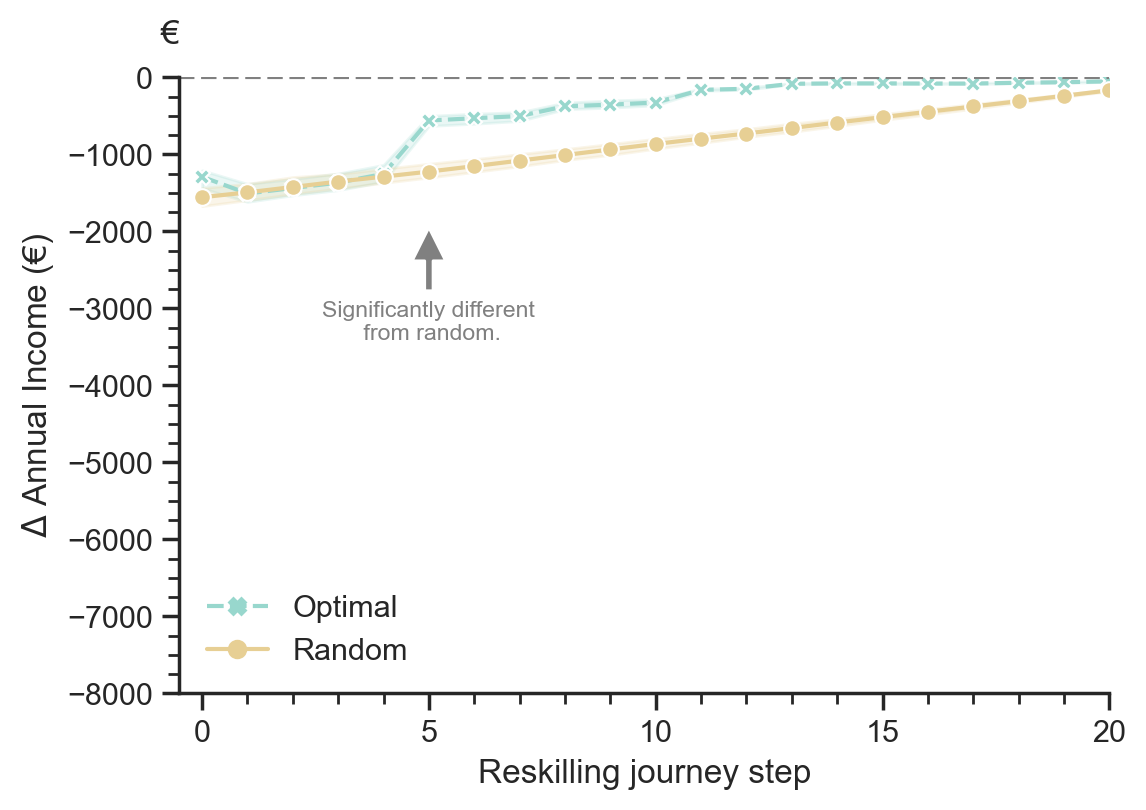

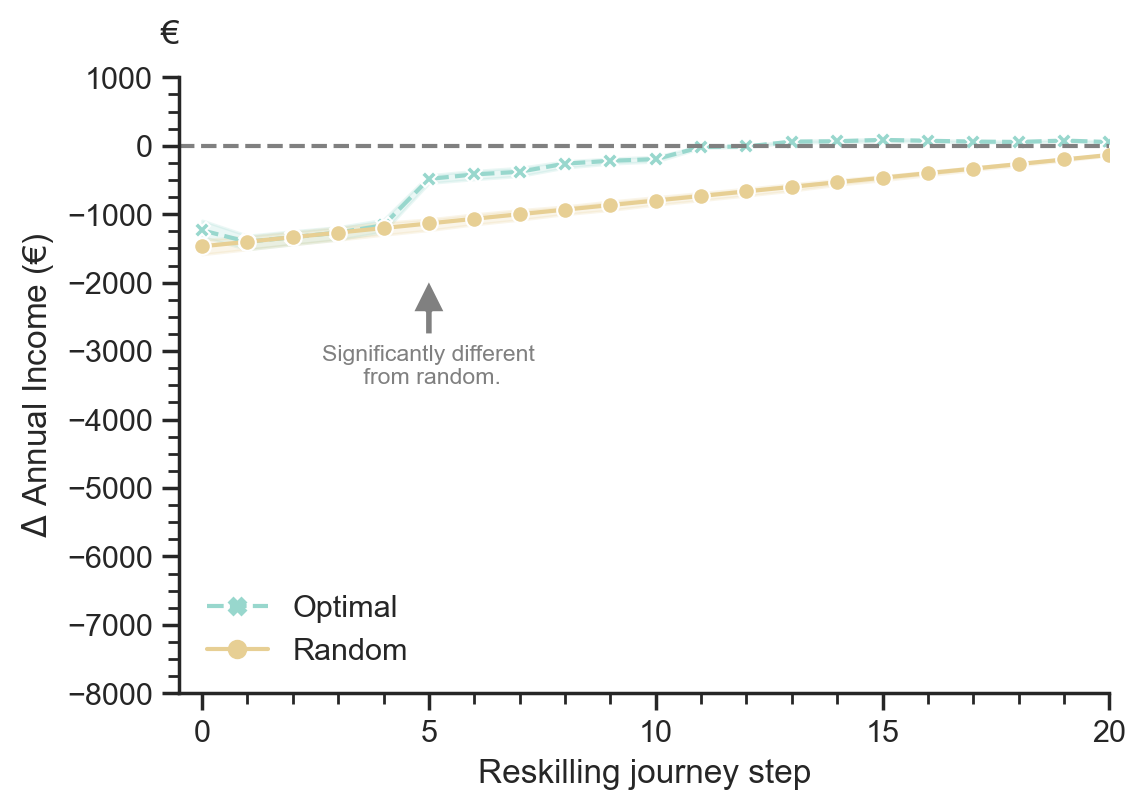

In [703]:
x = "reskilling_step"
y = "earnings_delta_rel"
hue = "reskilling_mode"
style = hue
hue_order_main = [
    "reskill-optimal",
    "reskill-random",
]
palette = "BrBG_r"

for reg_constraint in regional_constraints:
    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint) &
        (df_tidy_long_earnings_merged[hue].isin(hue_order_main))
    ]
    # lineplot
    figsize=(6, 4)
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order_main,
        estimator=estimator,
        errorbar=errorbar,
        n_boot=n_boot,
        markers=True,
        palette=palette,
    )

    # annotation
    x_sign, y_sign = 5, -1900
    text = "Significantly different\n from random.".format(x_sign)
    ax.annotate(
        text, xy=(x_sign, y_sign),
        xytext=(x_sign, y_sign-1000),
        fontsize="x-small",
        arrowprops=dict(facecolor='grey', shrink=0.05, width=3), color="grey",
        horizontalalignment='center', verticalalignment='top',
    )

    # annotate units to y-axis
    ax.annotate(yax_title_earnings, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, legends = ax.get_legend_handles_labels()
    legend_locs = [0, 1]
    handles_new = [handle if i in legend_locs else None for i, handle in enumerate(handles)]
    labels_new = ["Optimal", "Random"]
    ax.legend(handles=handles_new, labels=labels_new, fancybox=False, frameon=False, loc="lower left")

    # axes limits and ticks
    xmin = 0
    xmax = 20
    ax.set_xticks(np.arange(xmin, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(xmin, xmax+1, 1), minor=True)
    ax.set_xlim(-0.5, xmax)

    ymin = -8000
    ymax = 0 if reg_constraint == "regC" else 1000
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.arange(ymin, ymax, 250), minor=True)

    # styling
    ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel_earnings)
    sns.despine()

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs, data=data, x=x, y=y, order=order, hue=hue
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=True,
    )
    #annotator.apply_and_annotate()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

In [ ]:
# N of independent data points
data.loc[
    (data["regional_constraint"] == reg_constraint) &
    (data["reskilling_mode"] == "reskill-optimal") &
    (data["reskilling_step"] == 0) &
    (~data["earnings_delta_rel"].isna())
].shape

##### Fig 5b: Earnings changes across reskilling journey, Sectors, Appendix

In [ ]:
x = "reskilling_step"
y = "earnings_delta_rel"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label_short"
hue_order_main = ["reskill-optimal"]
palette = "viridis"
figsize=(6, 4)

# apply regional constraint?
for reg_constraint in regional_constraints:

    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint) &
        (df_tidy_long_earnings_merged[hue].isin(hue_order_main))
    ]

    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order_main,
        estimator=estimator,
        errorbar=None,
        n_boot=n_boot,
        markers=True,
        palette=palette,
        ax=ax
    )

    # annotate units to y-axis
    ax.annotate(yax_title_earnings, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, legends = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=legends[3:], fancybox=False, frameon=False)

    # axes limits and ticks
    xmin = 0
    xmax = 20
    ax.set_xticks(np.arange(xmin, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(xmin, xmax+1, 1), minor=True)
    ax.set_xlim(-0.5, xmax)

    ymin = -8000
    ymax = 1000 if reg_constraint == "regC" else 1000
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.arange(ymin, ymax, 250), minor=True)

    # styling
    ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel_earnings)
    sns.despine()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Sectors, Main

In [ ]:
x = "reskilling_step"
y = "earnings_delta_rel"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
style = "NACE1D_label_short"
hue_order_main = ["reskill-optimal"]
palette = "viridis"
figsize=(3, 2)

# apply regional constraint?
for reg_constraint in regional_constraints:

    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint) &
        (df_tidy_long_earnings_merged[hue].isin(hue_order_main))
    ]

    # lineplot
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order_main,
        estimator=estimator,
        errorbar=None,
        n_boot=n_boot,
        markers=True,
        palette=palette,
        ax=ax,
        legend=False
    )

    # annotate units to y-axis
    ax.annotate(yax_title_earnings, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # axes limits and ticks
    xmin = 0
    xmax = 20
    ax.set_xticks(np.arange(xmin, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(xmin, xmax+1, 1), minor=True)
    ax.set_xlim(-0.5, xmax)

    ymin = -8000
    ymax = 1000 if reg_constraint == "regC" else 1000
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.arange(ymin, ymax+1, 1000), minor=True)

    # styling
    ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    sns.despine()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Countries, Appendix

In [ ]:
x = "reskilling_step"
y = "earnings_delta_rel"
hue = "reskilling_mode"
style = "COUNTRYW"
hue_order_main = [
    "reskill-optimal",
]
palette = "viridis"

for reg_constraint in regional_constraints:
    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint) &
        (df_tidy_long_earnings_merged[hue].isin(hue_order_main))
    ]
    # lineplot
    figsize=(6, 4)
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order_main,
        estimator=estimator,
        errorbar=None,
        n_boot=n_boot,
        markers=True,
        palette=palette,
    )

    # annotate units to y-axis
    ax.annotate(yax_title_earnings, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # beautify legend
    handles, legends = ax.get_legend_handles_labels()
    ax.legend(handles=handles[3:], labels=legends[3:], fancybox=False, frameon=False, ncol=2)

    # axes limits and ticks
    xmin = 0
    xmax = 20
    ax.set_xticks(np.arange(xmin, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(xmin, xmax+1, 1), minor=True)
    ax.set_xlim(-0.5, xmax)

    ymin = -8000
    ymax = 1000 if reg_constraint == "regC" else 1000
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.arange(ymin, ymax+1, 250), minor=True)

    # styling
    ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel_earnings)
    sns.despine()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_si.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

##### Fig 5b: Earnings changes across reskilling journey, Countries, Main

In [ ]:
x = "reskilling_step"
y = "earnings_delta_rel"
hue = "reskilling_mode"
style = "COUNTRYW"
hue_order_main = [
    "reskill-optimal",
]
palette = "viridis"

for reg_constraint in regional_constraints:
    data = df_tidy_long_earnings_merged.loc[
        (df_tidy_long_earnings_merged["regional_constraint"] == reg_constraint) &
        (df_tidy_long_earnings_merged[hue].isin(hue_order_main))
    ]
    # lineplot
    figsize=(3, 2)
    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        style=style,
        hue_order=hue_order_main,
        estimator=estimator,
        errorbar=None,
        n_boot=n_boot,
        markers=True,
        palette=palette,
        legend=False
    )

    # annotate units to y-axis
    ax.annotate(yax_title_earnings, xy=(0, yax_title_scaling_earnings), xytext=(0, yax_title_scaling_earnings), xycoords="axes fraction", textcoords="offset points", ha="right")

    # axes limits and ticks
    xmin = 0
    xmax = 20
    ax.set_xticks(np.arange(xmin, xmax+1, 5), minor=False)
    ax.set_xticks(np.arange(xmin, xmax+1, 1), minor=True)
    ax.set_xlim(-0.5, xmax)

    ymin = -8000
    ymax = 1000 if reg_constraint == "regC" else 1000
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.arange(ymin, ymax+1, 1000), minor=True)

    # styling
    ax.axhline(0, linestyle="--", color="grey")
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    sns.despine()

    # save
    out_dir = os.path.join(results_dir, "{}_{}".format(errorbar[0], errorbar[1]))
    utils.ccdir(out_dir)
    plt.savefig(
        os.path.join(
            out_dir,
            "{}_{}_by_{}_and_{}_{}_main.png".format(job_pool, y, hue, style, reg_constraint),
        ),
        bbox_inches="tight",
        dpi=300,
    )

In [ ]:
assert 1 == 2

#### Transition numbers

##### Regional

Boxplot

In [ ]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order_main = [
    "baseline",
    "reskill-random",
    "reskill-coreWeight",
    "reskill-digital",
    "reskill-optimal",
]
order = ["no-regC", "regC"]
sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df_tidy,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order_main,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # country-level stripplot
    sns.stripplot(
        x=x,
        y=y,
        data=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]],
        order=order,
        hue_order=hue_order_main,
        hue=hue,
        dodge=True,
        marker="o",
        size=4,
        edgecolor="black",
        palette=palette,
        alpha=0.5,
        ax=ax,
    )
    ax.legend([], [], frameon=False)

    # # country-level scatterplot
    # sns.scatterplot(
    #     x=hue,
    #     y=y,
    #     data_transitions=df_final_by_country.loc[df_final_by_country["job_pool"] == col_order[i]].dropna(subset=["COUNTRYW"]),
    #     style="COUNTRYW",
    #     hue="COUNTRYW",
    #     marker='o',
    #     size=4,
    #     edgecolor="black",
    #     palette="Paired",
    #     alpha=0.5,
    #     ax=ax,
    # )

    # styling
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(
        ax,
        pairs,
        data=df_tidy,
        x=x,
        y=y,
        order=order,
        hue=hue,
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "test"
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
df_final_by_country.query(
    "(job_pool=='CPO') & (reskilling_mode=='baseline') & (regional_constraint=='no-regC')"
)

In [ ]:
x = "regional_constraint"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = True
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    ci="sd",
    height=5,
    aspect=1,
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:

    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

Hue = regional constraint

In [ ]:
x = "reskilling_mode"
y = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "regional_constraint"
col = "job_pool"
# order = ["no-regC", "regC"]
sharey = True

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    hue=hue,
    # order=order,
    kind="box",
    sharey=sharey,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

axes = g.axes.flatten()
for ax in axes:
    ax.axhline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel(None)

    # test statistic
    annotator = Annotator(ax, pairs_regional_hue, data=df_regions, x=x, y=y, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Job transition options (-)")

##### Sectors

In [ ]:
sectors = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]

pairs_sectors = []
for sector in sectors:
    # with regional constraints
    pair = ((sector, "baseline"), (sector, "reskill-optimal"))
    pairs_sectors.append(pair)

In [ ]:
reskilling_modes = ["baseline", "reskill-optimal"]
df = df_sectors.loc[
    df_sectors["paper_selection"] & df_sectors["reskilling_mode"].isin(reskilling_modes)
]

y = "NACE1D_label_short"
x = "n_viable_transitions"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"

order = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]
col_order = ["FFPO", "FFPOTC", "CPO"]
hue_order_main = [
    "baseline",
    "reskill-optimal",
]

sharey = True
kind = "box"

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order_main,
    kind=kind,
    sharey=sharey,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # styling
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel("Job transition options (-)")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs_sectors, data=df, x=x, y=y, order=order, hue=hue, orient="h"
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_sector_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
axes

#### Income changes

John Tukey, who was a driving force in the development of exploratory data analysis, defined outliers as points more than 1.5 x IQR. Recall that IQR is the inter-quartile range, which captures 50% of the data points in a data set.

[https://neuraldatascience.io/5-eda/data_cleaning.html]()


##### Regions

Hue = reskilling mode

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.sum,
    height=5,
    aspect=1,
    ci=None,
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=True,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_sum.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "bar"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    estimator=np.mean,
    height=5,
    aspect=1,
    ci="sd",
    palette="BrBG"
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black")
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}_mean.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
x = "regional_constraint"
y = "earnings_delta_closest_switch_sum_mio"  # "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
order = ["no-regC", "regC"]
sharey = False
kind = "box"

g = sns.catplot(
    data=df_regions,
    col=col,
    x=x,
    y=y,
    order=order,
    hue=hue,
    kind=kind,
    sharey=sharey,
    height=5,
    aspect=1,
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    palette="BrBG",
)

# annotate stats
axes = g.axes.flatten()
for ax in axes:
    ax.axhline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel(None)
    # test statistic
    annotator = Annotator(ax, pairs, data=df_regions, x=x, y=y, order=order, hue=hue)
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format=text_format,
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

axes[0].set_ylabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_delta_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

##### Sectors

In [ ]:
reskilling_modes = ["baseline", "reskill-optimal"]
df = df_sectors.loc[
    df_sectors["paper_selection"] & df_sectors["reskilling_mode"].isin(reskilling_modes)
]

y = "NACE1D_label_short"
x = "earnings_delta_closest_switch_sum_mio"  # n_viable_transitions / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"

order = [
    "Manufacturing",
    "Construction",
    "Electricity, Gas",
    "Agri., Forest., Fish.",
    "Mining",
    "Water, Waste Mgmt.",
    "Trade, Repair",
    "Transport",
]
col_order = ["FFPO", "FFPOTC", "CPO"]
hue_order_main = [
    "baseline",
    "reskill-optimal",
]

sharey = True
sharex = False
kind = "bar"

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order_main,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci="sd",
    # flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

# annotate stats
axes = g.axes.flatten()
for i, ax in enumerate(axes):

    # styling
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_ylabel(None)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

    # test statistic
    annotator = Annotator(
        ax=ax, pairs=pairs_sectors, data=df, x=x, y=y, order=order, hue=hue, orient="h"
    )
    annotator.configure(
        alpha=alpha,
        test=test,
        comparisons_correction=comparisons_correction,
        text_format="star",
        loc=loc,
        show_test_name=show_test_name,
        verbose=verbose,
    )
    annotator.apply_and_annotate()

plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_income_by_sector_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

#### Results by country

In [ ]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order_main = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "box"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order_main,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for ax in axes:
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
y = "COUNTRYW"
x = "n_viable_transitions"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order_main = ["reskill-optimal", "baseline"]
sharey = True
sharex = True
kind = "bar"
palette = "BrBG_r"

# make country-level grouped stripplot
aggdict = {
    "n_viable_transitions": np.mean,
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=False)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order_main,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    ci="sd",
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=7,
    aspect=1,
    palette=palette,
)

aggdict = {
    "n_viable_transitions": [np.mean, np.std],
    "earnings_delta_closest_switch_sum_mio": np.mean,
    "viability_threshold": "first",
}
df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot.columns = ["_".join(col) for col in df_annot.columns]
df_annot = df_annot.reindex(order, level=1).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(1, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Job transition options (-)")  # "Annual earnings changes (M€, 2019)"

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        labels = (
            df_hue.loc[:, "n_viable_transitions_mean"].round(1).astype(str)
            + r" $\pm$ "
            + df_hue.loc[:, "n_viable_transitions_std"].round(1).astype(str)
        )
        ax.bar_label(container, labels=labels, fontsize=8, label_type="center")

        # annotate mean
        x = df_hue["n_viable_transitions_mean"].mean()
        c = container[-1].get_facecolor()
        ax.axvline(x, linestyle="--", color=c, label=r"$\mu$")  # , zorder=0)

        ax.text(
            x,
            0,
            "$\mu = {:.1f}$".format(x),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_transitions_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
ax.containers[0][-1].get_facecolor()

In [ ]:
df_hue

In [ ]:
df_annot

In [ ]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order_main = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "box"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
    & (~df_regions["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order_main,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    # ci="sd",
    flierprops=dict(markerfacecolor="0.75", markersize=5, linestyle="none"),
    showmeans=True,
    meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=8,
    aspect=1,
    palette=palette,
)

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.grid(linestyle=":", axis="x")
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
y = "COUNTRYW"
x = "earnings_delta_closest_switch_sum_mio"  # "n_viable_transitions" / "earnings_delta_closest_switch_sum_mio"
hue = "reskilling_mode"
col = "job_pool"
col_order = ["CPO", "FFPOTC", "FFPO"]
hue_order_main = ["reskill-optimal", "baseline"]
sharey = True
sharex = False
kind = "bar"
palette = "BrBG_r"

aggdict = {
    "n_viable_transitions": np.median,
    "earnings_delta_closest_switch_sum_mio": np.sum,
    "viability_threshold": "first",
}

# calc order
df = df_regions.loc[
    (df_regions["reskilling_mode"].isin(["baseline", "reskill-optimal"]))
    & (df_regions["regional_constraint"] == "regC")
    & (~df_regions["COUNTRYW"].isin(earnings_data_missing))
]
order = (
    df.loc[
        (
            df_regions["reskilling_mode"].isin(["baseline"])
            & (df_regions["job_pool"] == "CPO")
        )
    ]
    .groupby("COUNTRYW")
    .agg(aggdict)
    .reset_index()
    .sort_values(x, ascending=True)
    .loc[:, "COUNTRYW"]
)

# boxplots
g = sns.catplot(
    data=df,
    col=col,
    x=x,
    y=y,
    hue=hue,
    order=order,
    col_order=col_order,
    hue_order=hue_order_main,
    kind=kind,
    sharey=sharey,
    sharex=sharex,
    estimator=np.sum,
    ci=False,
    # flierprops=dict(markerfacecolor='0.75', markersize=5, linestyle='none'),
    # showmeans=True,
    # meanprops=dict(markerfacecolor="white", markeredgecolor="black"),
    height=5,
    aspect=1,
    palette=palette,
)

df_annot = df.groupby(["job_pool", "COUNTRYW", "reskilling_mode"]).agg(aggdict)
df_annot = df_annot.reindex(order, level=0).reset_index()

# annotate vline
axes = g.axes.flatten()
for i, ax in enumerate(axes):
    ax.axvline(0, linestyle="--", color="lightgrey", zorder=0)
    ax.set_xlabel("Annual earnings changes (M€, 2019)")
    ax.grid(linestyle=":", axis="x")

    # annotate numbers (one container per hue level)
    for container in ax.containers:
        df_hue = df_annot.loc[
            (df_annot[hue] == container.get_label())
            & (df_annot["job_pool"] == col_order[i])
        ]
        ax.bar_label(
            container, labels=df_hue[x], fmt="%.0f", fontsize=8, label_type="edge"
        )
        # annotate mean
        pos = np.nanmean(df_hue["earnings_delta_closest_switch_sum_mio"])
        c = container[-1].get_facecolor()
        ax.axvline(pos, linestyle="--", color=c, label=r"$\mu$")  # , zorder=0)

        ax.text(
            pos,
            0,
            r"$\mu = {:.1f}$".format(pos),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=8,
        )

# save
# plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "reskilling_final_thresh-{}".format(threshold),
        "model_run_comparison_earnings_by_country_{kind}.png".format(kind=kind),
    ),
    bbox_inches="tight",
    dpi=300,
)

In [ ]:
df_hue